<a href="https://colab.research.google.com/github/ikoghoddds-bit/Data-Science-Portfolio-C21/blob/main/Projects/Project-6/Images-Description.for.Students_Pass_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 6: Image Classification with Deep Learning



This project introduces us to deep learning. The deep learning process is a huge leap forward in data science and the field is less than 15 years old. The processing is significantly different from our previous projects so you will basically be provided a walkthrough document delineating the steps - much like Project 1. Deep learning is fascinating and I just want you to go through the process so you can appreciate its power.



The data collection portion of deep learning projects is a rather complex task. In other words, there is no CSV file that we can load to serve as our training data. Constructing a training data set is a rather large undertaking. We have imported all the training images (took hours) and I will show you how you can load the training data through the "pickle" process.



There are three files in this data set:
- [the feature set]( https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle ), i.e. images of dogs and cats ( mostly )
- [the target set]( https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle ), i.e. the label (0/1) that something is a dog or cat ( mostly )
- [a test image]( https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/dog.jpg )





This project will classify new, unseen images of cats and dogs. This was one of the first big success stories of deep learning and we will go through the process of building a learning algorithm that will do this task. Distinguishing a picture of a cat from a picture of a dog is easy for humans to do, but had been notoriously difficult to get a computer learning to perform well on the task. Deep learning solved that.


The same data sets as above, but you can copy the links by viewing the markdown directly to bypass Google Colab's annoying "You are leaving Colab" link.




https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle

https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle

https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/dog.jpg


In [2]:
import pandas as pd


In [1]:
images_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle"
images_url


'https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle'

In [3]:
image_array = pd.read_pickle( images_url )
type(image_array)


numpy.ndarray

In [4]:
image_array.shape

(24946, 100, 100, 1)

In [5]:
target_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle"
target_url


'https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle'

In [6]:
target = pd.read_pickle( target_url )
type(target)


list

In [7]:
image_url = ''

## Library Imports

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.datasets import cifar10

## Verify GPU Enabled

In [9]:
# Verify GPU

print("GPU Devices Available: ", tf.config.list_physical_devices('GPU'))

GPU Devices Available:  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Data Collection

### Load The New Multi Class Dataset

In [10]:
# Load the new multi-class dataset

(X_train_full, y_train_full), (X_test_full, y_test_full) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1306s 8us/step


In [12]:
# CIFAR-10 labels: 3=Cat, 5=Dog, 7=Horse

target_classes = [3, 5, 7]

In [13]:
# Create masks to filter only the 3 animals

train_mask = np.isin(y_train_full, target_classes).flatten()
test_mask = np.isin(y_test_full, target_classes).flatten()

X_train_sub = X_train_full[train_mask]
y_train_sub = y_train_full[train_mask].flatten()

X_test_sub = X_test_full[test_mask]
y_test_sub = y_test_full[test_mask].flatten()

In [14]:
# Remap labels to 0, 1, 2 for the neural network

label_mapping = {3: 0, 5: 1, 7: 2}
y_train = np.vectorize(label_mapping.get)(y_train_sub)
y_test = np.vectorize(label_mapping.get)(y_test_sub)

In [15]:
# Data Cleaning (Scaling)

X_train = X_train_sub / 255.0
X_test = X_test_sub / 255.0

### Exploratory Data Analysis (EDA)

Verify the new shapes. CIFAR-10 images are 32x32 with 3 color channels.

In [16]:
# Verify Dimensionality

print(f"X_train shape: {X_train.shape}") # Should be (15000, 32, 32, 3)
print(f"y_train shape: {y_train.shape}") # Should be (15000,)

X_train shape: (15000, 32, 32, 3)
y_train shape: (15000,)


### Visual Inspection and Label Verification

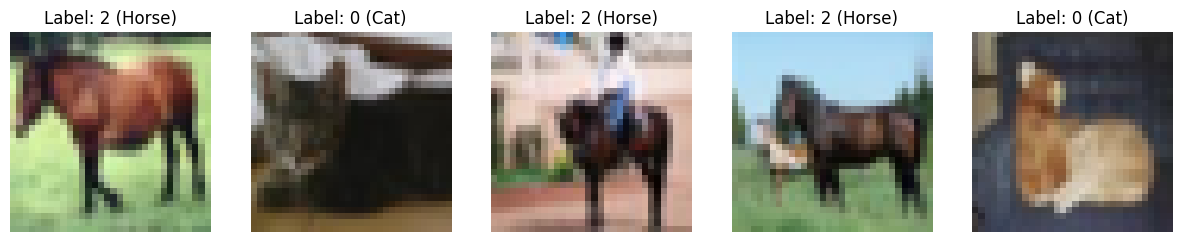

In [17]:
# Visual Inspection and Label Verification

class_names = {0: "Cat", 1: "Dog", 2: "Horse"}

plt.figure(figsize=(15, 3))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_train[i]) # No reshape needed, matplotlib handles (32, 32, 3) automatically
    plt.title(f"Label: {y_train[i]} ({class_names[y_train[i]]})")
    plt.axis('off')
plt.show()

## CNN Architecture & Compilation

#### Here we apply the structural changes requested:

- ***Added Layers / Node Changes:*** We expanded to three Convolutional blocks, increasing node density heavily (64 -> 128 -> 256) to capture the complex color features of 3 different animals.

- ***Activation Changes:*** Swapped relu for elu (Exponential Linear Unit), which often clears up the "dying ReLU" problem and speeds up learning.

- ***Other Hyperparameters:*** Added padding='same' to keep feature maps from shrinking too fast, injected L2 Regularization into the final Conv2D layer to penalize massive weights (combating overfitting), and explicitly defined the Adam learning rate.

- ***Multi-Class Output:*** Since we now have 3 animals, the output layer uses Dense(3) and the softmax activation function (which outputs an array of 3 probabilities that sum to 1). I also switched the loss function to sparse_categorical_crossentropy.

### Train_Test Split

In [18]:
model = Sequential()

# Block 1 (Changed nodes to 64, activation to 'elu', added padding)

model.add(Conv2D(64, kernel_size=(3, 3), activation='elu', padding='same', input_shape=(32, 32, 3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

# Block 2 (Changed nodes to 128)

model.add(Conv2D(128, kernel_size=(3, 3), activation='elu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

# Block 3 (New Layer: 256 nodes, with L2 regularization hyperparameter)

model.add(Conv2D(256, kernel_size=(3, 3), activation='elu', padding='same', kernel_regularizer=l2(0.001)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

# Output Layers

model.add(Flatten())
model.add(Dense(128, activation='elu'))
model.add(Dropout(0.4)) # Hyperparameter: Dropout rate at 40%

# CHANGED: 3 nodes for 3 animals, 'softmax' activation for multi-class

model.add(Dense(3, activation='softmax'))

# Compile (Customizing the Adam learning rate hyperparameter)

custom_optimizer = Adam(learning_rate=0.0005)
model.compile(optimizer=custom_optimizer,
              loss='sparse_categorical_crossentropy', # CHANGED for multi-class
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 897,411 (3.42 MB)

 Trainable params: 896,515 (3.42 MB)

 Non-trainable params: 896 (3.50 KB)

## Training and Prediction

#### Training the multi-class model on the GPU using Early Stopping to monitor the new architecture's performance.

In [19]:
from tensorflow.keras.callbacks import EarlyStopping

In [20]:
# Define EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)

# Fit the Model

history = model.fit(
    X_train, y_train,
    epochs=25,
    validation_data=(X_test, y_test),
    batch_size=64,
    callbacks=[early_stop]
)

# Evaluate Performance

loss, accuracy = model.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {accuracy*100:.2f}%")

Epoch 1/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 16s 35ms/step - accuracy: 0.5478 - loss: 1.3216 - val_accuracy: 0.3503 - val_loss: 2.7668
Epoch 2/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6293 - loss: 1.0140 - val_accuracy: 0.5947 - val_loss: 1.1166
Epoch 3/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6893 - loss: 0.8700 - val_accuracy: 0.7007 - val_loss: 0.8152
Epoch 4/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7416 - loss: 0.7433 - val_accuracy: 0.7533 - val_loss: 0.7406
Epoch 5/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7713 - loss: 0.6565 - val_accuracy: 0.7270 - val_loss: 0.7982
Epoch 6/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8001 - loss: 0.5836 - val_accuracy: 0.7547 - val_loss: 0.6988
Epoch 7/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8293 - loss: 0.5160 - val_accuracy: 0.7440 - val_loss: 0.8066
Epoch 8/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8588 - loss: 0.4491 - val_accuracy

## Pass 8 Analytical Review

- Because there are 3 classes and are using softmax, the model no longer outputs a single probability. It outputs an array of 3 probabilities per image (e.g., [0.1, 0.8, 0.1] means it is 80% confident the image is class 1 - Dog). I am using a confusion matrix to evaluate where the model gets confused between the three animals.

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [22]:
# Generate predictions (this returns arrays of 3 probabilities)

raw_predictions = model.predict(X_test)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


In [23]:
# Convert probabilities to actual class predictions by finding the index with the highest probability

class_predictions = np.argmax(raw_predictions, axis=1)

#### Generate Confusion Matrix

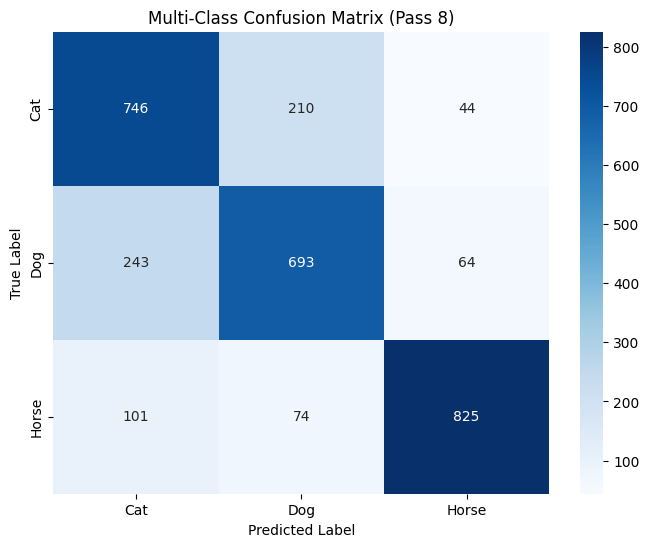

In [24]:
# Generate Confusion Matrix

cm = confusion_matrix(y_test, class_predictions)

# Plot Confusion Matrix

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Cat", "Dog", "Horse"],
            yticklabels=["Cat", "Dog", "Horse"])
plt.title("Multi-Class Confusion Matrix (Pass 8)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

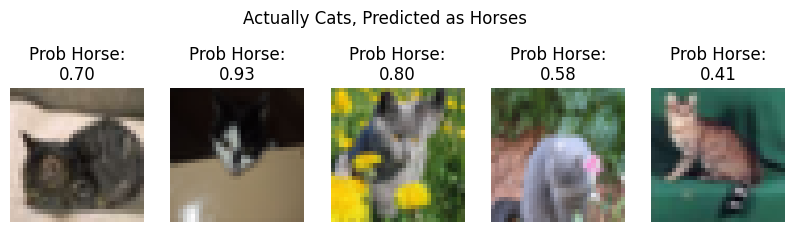

In [25]:
# Visualize a few high-confidence errors (e.g., Actually Cat, Predicted Horse)

errors = np.where((y_test == 0) & (class_predictions == 2))[0]
if len(errors) > 0:
    plt.figure(figsize=(10, 3))
    plot_count = min(len(errors), 5)
    for i in range(plot_count):
        idx = errors[i]
        plt.subplot(1, 5, i+1)
        plt.imshow(X_test[idx])

        # Show the confidence the model had that it was a horse (index 2)

        plt.title(f"Prob Horse:\n{raw_predictions[idx][2]:.2f}")
        plt.axis('off')
    plt.suptitle("Actually Cats, Predicted as Horses")
    plt.show()